PREN2 Step Generator - Ramp Analysis Summary

SYSTEM CONFIGURATION:
  Timer frequency:        120,000 Hz
  ISR period:             8.33 µs

AXIS PARAMETERS:
  Steps/rev:              200
  Microstepping:          1/16
  Circumference:          50 mm
  Steps/mm:               64.00

MOTION PROFILE:
  Max speed:              150 mm/s
  Max speed (steps):      9600.00 steps/s
  Acceleration:           700 mm/s²
  Acceleration (steps):   44800.00 steps/s²
  Cruise interval:        12 ticks

RAMP TABLE:
  Theoretical steps:      1028 (v²/2a)
  Corrected steps:        3085 (2.5× factor)
  Correction ratio:       3.001×

CONVERGENCE ANALYSIS:
  Target cruise velocity: 9600.00 steps/s
  Final ramp velocity:    10909.09 steps/s
  Error:                  1309.09 steps/s (13.64%)

TIMING:
  Accel ramp duration:    545.72 ms
  Total accel distance:   48.20 mm

Generating plots...
  ✓ Saved: ramp_table.png
  ✓ Saved: correction_factor.png
  ✓ Saved: move_profile_short.png (4627 steps)
  ✓ Saved: mo

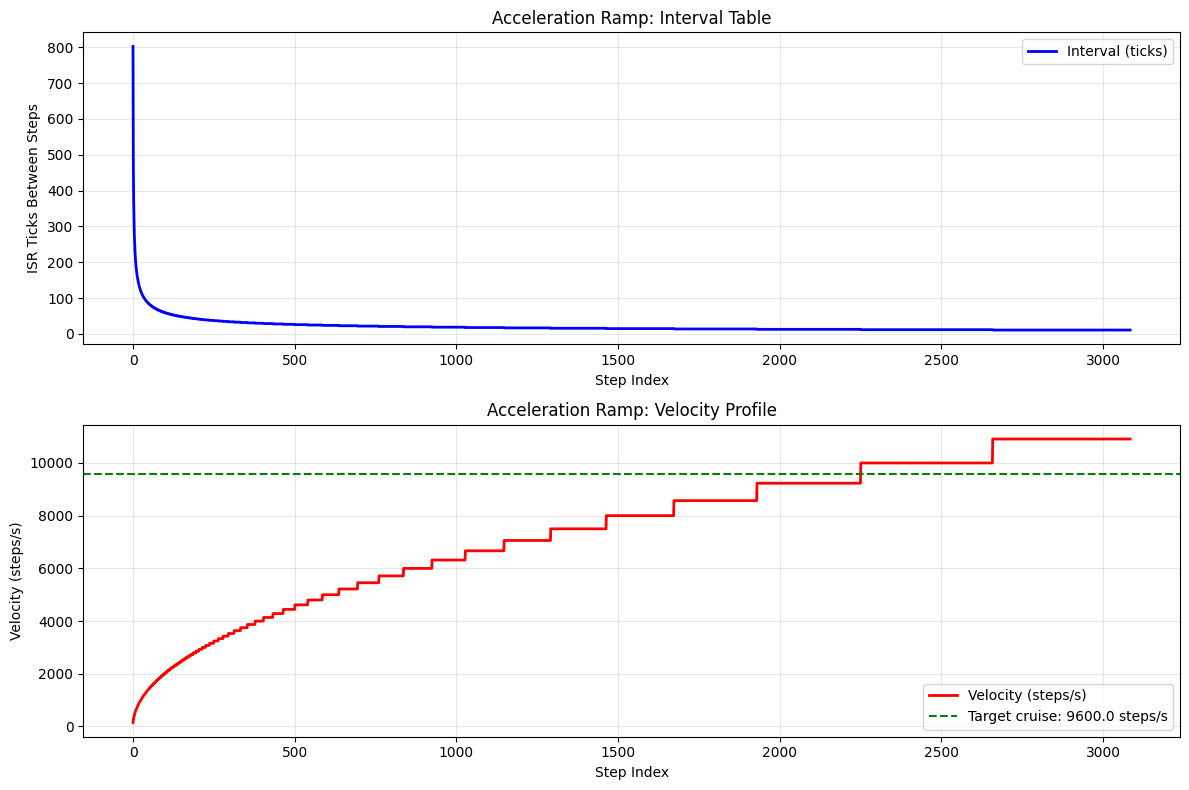

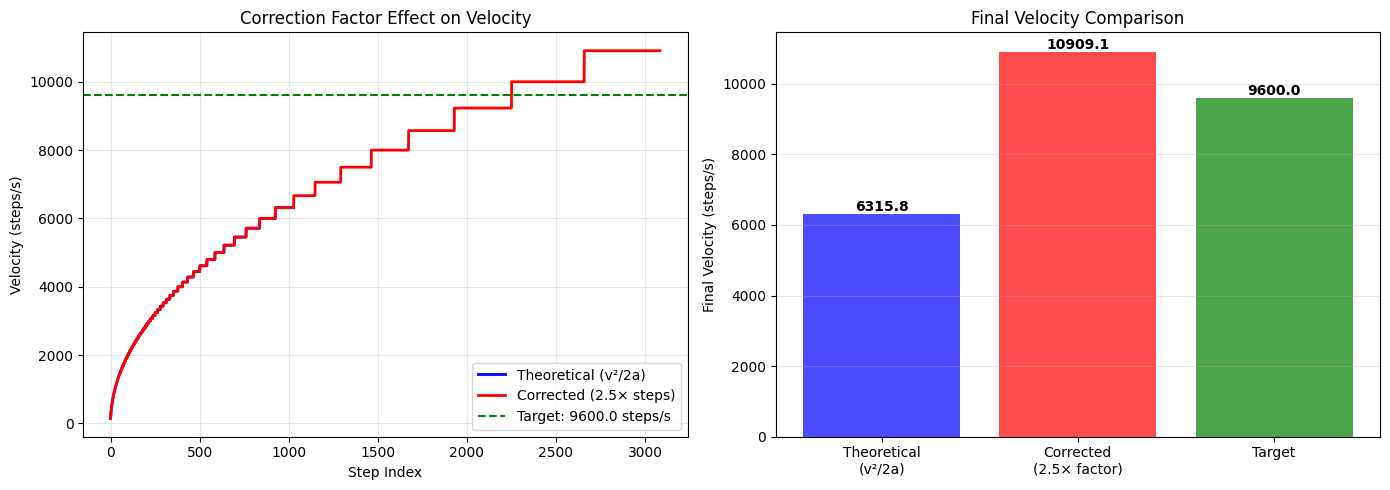

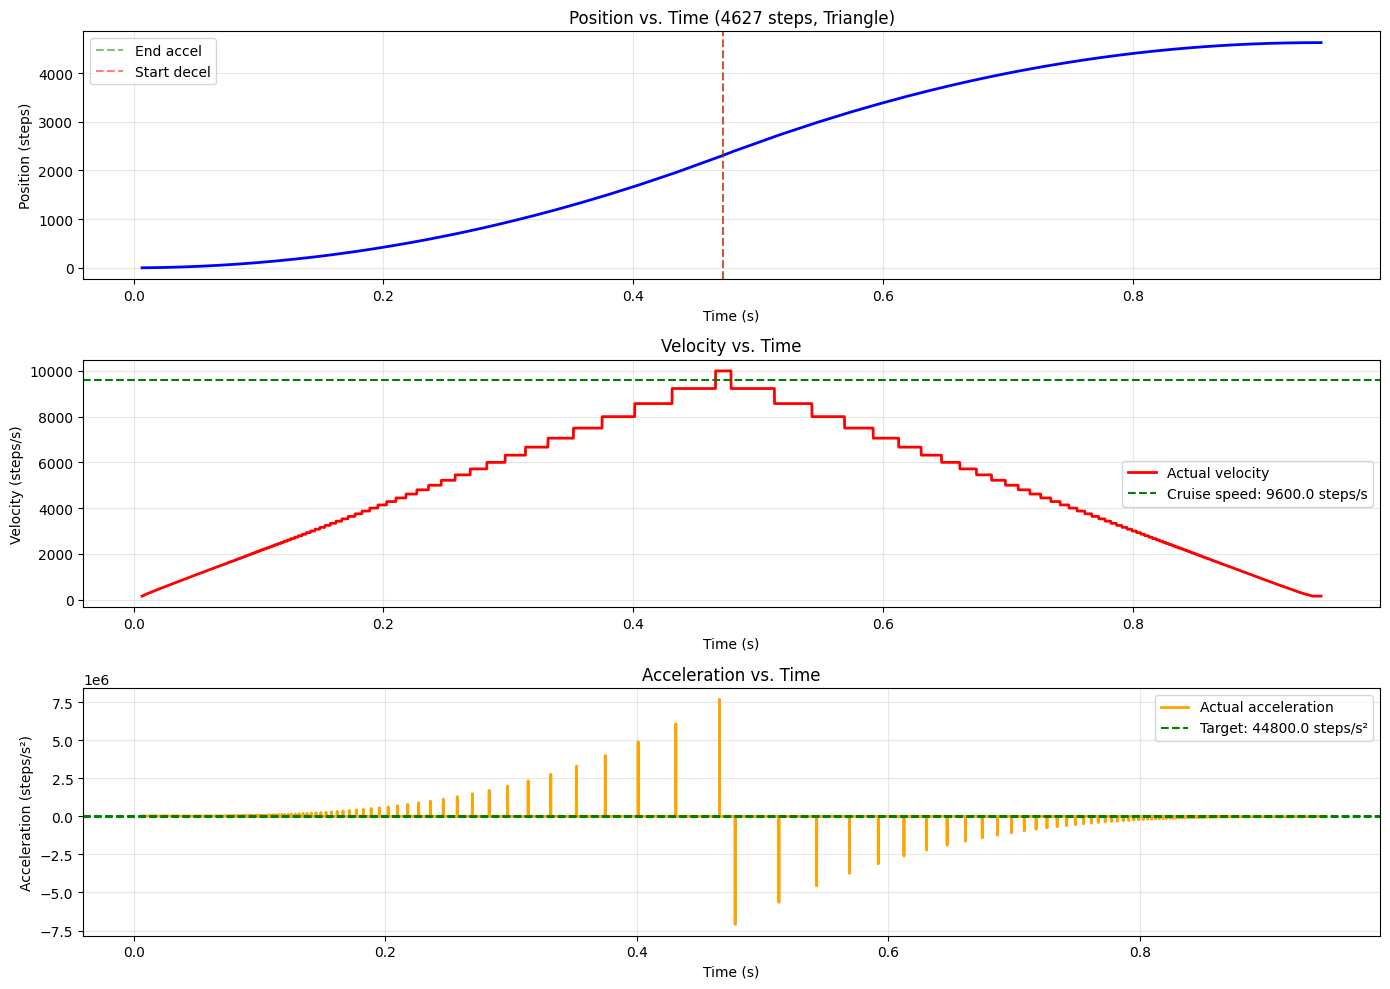

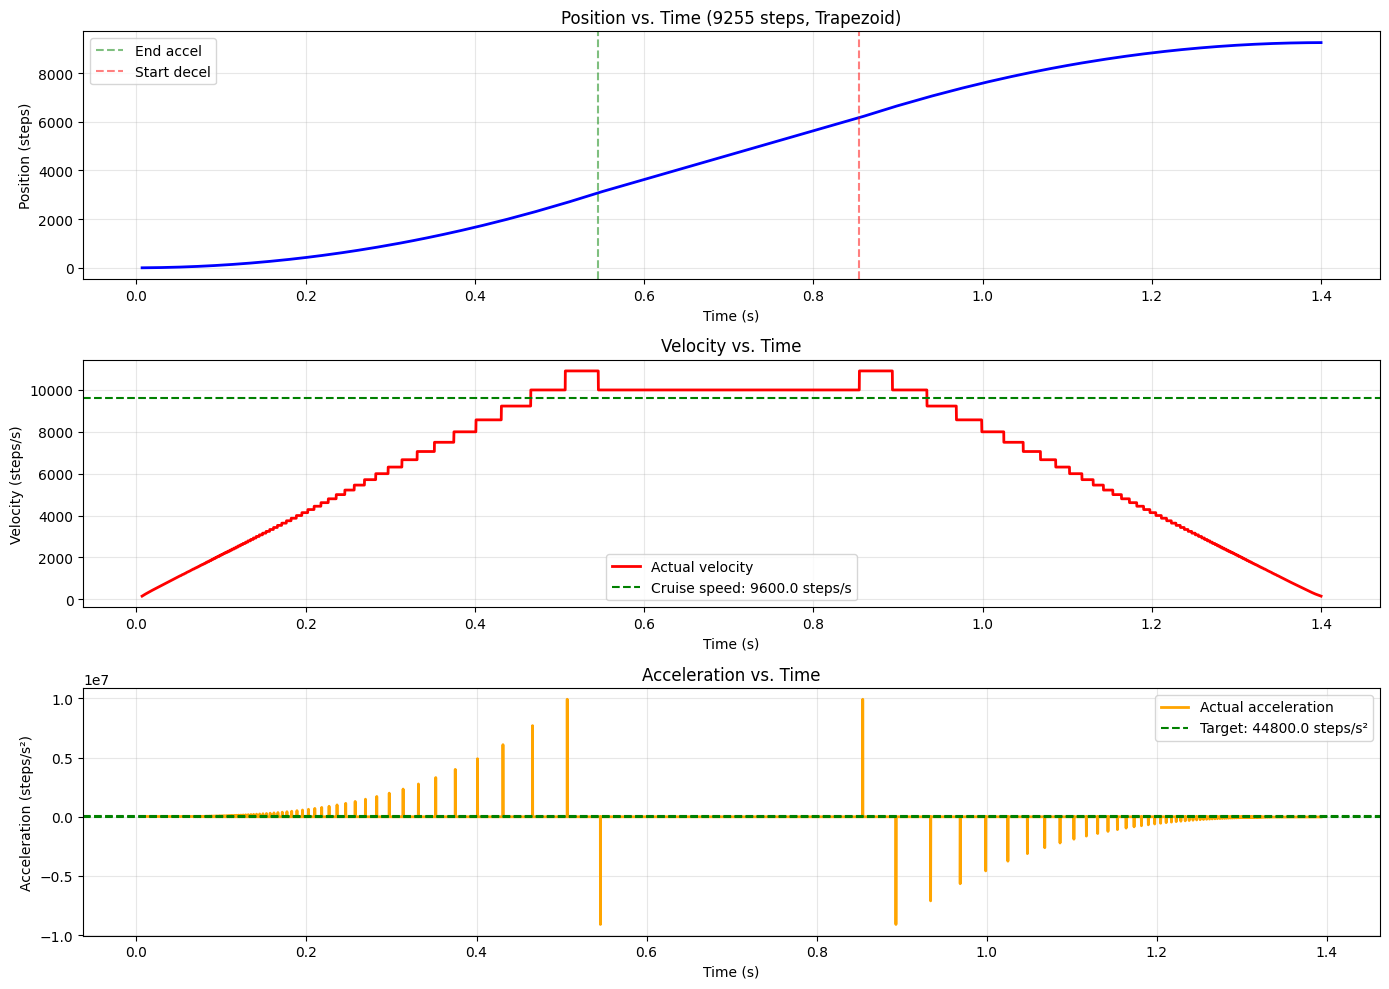

In [4]:
"""
Ramp Analysis Tool for PREN2 Step Generator
============================================

Visualizes and validates the Austin acceleration formula implementation
used in the stepper motor step generator.

Tests:
- Acceleration ramp interval calculation
- Speed profile (trapezoidal and triangular)
- Distance vs. time
- Theoretical vs. actual behavior
- Correction factor validation
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, List


@dataclass
class SystemConfig:
    """Configuration matching sys_config.h"""
    # Timer
    TIMER_FREQ_HZ: int = 120000
    
    # Axis configuration
    STEPS_PER_REV: int = 200
    MICRO: int = 16
    CIRCUMFERENCE_MM: int = 50
    
    MAX_SPEED_MM_S: int = 150
    ACCEL_MM_S2: int = 700
    
    @property
    def steps_per_mm(self) -> float:
        return (self.MICRO * self.STEPS_PER_REV) / self.CIRCUMFERENCE_MM
    
    @property
    def max_v_steps(self) -> float:
        return self.MAX_SPEED_MM_S * self.steps_per_mm
    
    @property
    def accel_steps_s2(self) -> float:
        return self.ACCEL_MM_S2 * self.steps_per_mm
    
    @property
    def cruise_interval(self) -> int:
        return int(self.TIMER_FREQ_HZ / self.max_v_steps)
    
    @property
    def accel_steps_ideal(self) -> int:
        """Corrected acceleration steps with 2.5x factor"""
        v = self.max_v_steps
        a = self.accel_steps_s2
        return int(300 * (v * v) / (2 * a * 100))
    
    @property
    def accel_steps_theoretical(self) -> int:
        """Theoretical acceleration steps (v²/2a) without correction"""
        v = self.max_v_steps
        a = self.accel_steps_s2
        return int((v * v) / (2 * a))


class RampGenerator:
    """Replicates the C implementation of StepGenerator_BuildRampTable()"""
    
    def __init__(self, config: SystemConfig):
        self.config = config
        self.interval_table = self._build_ramp_table()
    
    def _build_ramp_table(self) -> np.ndarray:
        """Austin formula implementation matching the C code"""
        table_len = self.config.accel_steps_ideal
        intervals = np.zeros(table_len, dtype=np.uint32)
        
        c = float(self.config.TIMER_FREQ_HZ) * np.sqrt(2.0 / self.config.accel_steps_s2)
        intervals[0] = int(c + 0.5)  # rounded
        
        for k in range(1, table_len):
            c = c - (2.0 * c) / (4.0 * k + 1)
            intervals[k] = int(c + 0.5)
        
        return intervals
    
    def generate_move_block(self, path_steps: int) -> dict:
        """Generates a move block matching StepGenerator_GenerateBlock()"""
        
        if path_steps >= 2 * self.config.accel_steps_ideal:
            # Trapezoidal profile
            accel_steps = self.config.accel_steps_ideal
            decel_at = path_steps - self.config.accel_steps_ideal
        else:
            # Triangular profile
            accel_steps = path_steps // 2
            decel_at = accel_steps
        
        return {
            'path_steps': path_steps,
            'accel_until': accel_steps,
            'decel_at': decel_at,
            'cruise_interval': self.config.cruise_interval,
            'table_len': accel_steps,
            'is_trapezoid': path_steps >= 2 * self.config.accel_steps_ideal
        }
    
    def simulate_move(self, path_steps: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        Simulates a complete move and returns time, position, and velocity arrays.
        
        Returns:
            time (seconds), position (steps), velocity (steps/s)
        """
        block = self.generate_move_block(path_steps)
        
        time_ticks = []
        position = []
        velocity = []
        
        current_tick = 0
        current_pos = 0
        
        for step_idx in range(path_steps):
            # Determine interval for this step
            if step_idx < block['accel_until']:
                interval = self.interval_table[step_idx]
            elif step_idx < block['decel_at']:
                interval = block['cruise_interval']
            else:
                decel_steps_done = step_idx - block['decel_at']
                if decel_steps_done >= block['table_len']:
                    interval = self.interval_table[0]
                else:
                    mirror = block['table_len'] - decel_steps_done - 1
                    interval = self.interval_table[mirror]
            
            current_tick += interval
            current_pos += 1
            
            # Calculate instantaneous velocity (steps/s)
            v = self.config.TIMER_FREQ_HZ / interval if interval > 0 else 0
            
            time_ticks.append(current_tick)
            position.append(current_pos)
            velocity.append(v)
        
        # Convert to numpy arrays
        time_s = np.array(time_ticks) / self.config.TIMER_FREQ_HZ
        position = np.array(position)
        velocity = np.array(velocity)
        
        return time_s, position, velocity


def plot_ramp_table(config: SystemConfig, ramp_gen: RampGenerator):
    """Plots the acceleration ramp interval table"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    steps = np.arange(len(ramp_gen.interval_table))
    intervals = ramp_gen.interval_table
    
    # Interval vs. step
    ax1.plot(steps, intervals, 'b-', linewidth=2, label='Interval (ticks)')
    ax1.set_xlabel('Step Index')
    ax1.set_ylabel('ISR Ticks Between Steps')
    ax1.set_title('Acceleration Ramp: Interval Table')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Instantaneous velocity
    velocity = config.TIMER_FREQ_HZ / intervals
    ax2.plot(steps, velocity, 'r-', linewidth=2, label='Velocity (steps/s)')
    ax2.axhline(y=config.max_v_steps, color='g', linestyle='--', 
                label=f'Target cruise: {config.max_v_steps:.1f} steps/s')
    ax2.set_xlabel('Step Index')
    ax2.set_ylabel('Velocity (steps/s)')
    ax2.set_title('Acceleration Ramp: Velocity Profile')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    return fig


def plot_move_profile(config: SystemConfig, ramp_gen: RampGenerator, path_steps: int):
    """Plots complete move profile: position, velocity, and acceleration"""
    time_s, position, velocity = ramp_gen.simulate_move(path_steps)
    block = ramp_gen.generate_move_block(path_steps)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10))
    
    # Position vs. time
    ax1.plot(time_s, position, 'b-', linewidth=2)
    ax1.axvline(x=time_s[block['accel_until']-1] if block['accel_until'] > 0 else 0, 
                color='g', linestyle='--', alpha=0.5, label='End accel')
    ax1.axvline(x=time_s[block['decel_at']-1] if block['decel_at'] > 0 else 0, 
                color='r', linestyle='--', alpha=0.5, label='Start decel')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Position (steps)')
    ax1.set_title(f'Position vs. Time ({path_steps} steps, {"Trapezoid" if block["is_trapezoid"] else "Triangle"})')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Velocity vs. time
    ax2.plot(time_s, velocity, 'r-', linewidth=2, label='Actual velocity')
    ax2.axhline(y=config.max_v_steps, color='g', linestyle='--', 
                label=f'Cruise speed: {config.max_v_steps:.1f} steps/s')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Velocity (steps/s)')
    ax2.set_title('Velocity vs. Time')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Acceleration (numerical derivative)
    if len(velocity) > 1:
        accel = np.diff(velocity) / np.diff(time_s)
        ax3.plot(time_s[:-1], accel, 'orange', linewidth=2, label='Actual acceleration')
        ax3.axhline(y=config.accel_steps_s2, color='g', linestyle='--', 
                    label=f'Target: {config.accel_steps_s2:.1f} steps/s²')
        ax3.axhline(y=-config.accel_steps_s2, color='g', linestyle='--')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Acceleration (steps/s²)')
    ax3.set_title('Acceleration vs. Time')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    return fig


def plot_correction_factor_analysis(config: SystemConfig):
    """Analyzes the 2.5x correction factor"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Build ramp without correction (theoretical)
    theoretical_steps = config.accel_steps_theoretical
    c = float(config.TIMER_FREQ_HZ) * np.sqrt(2.0 / config.accel_steps_s2)
    
    intervals_theoretical = []
    intervals_theoretical.append(int(c + 0.5))
    for k in range(1, theoretical_steps):
        c = c - (2.0 * c) / (4.0 * k + 1)
        intervals_theoretical.append(int(c + 0.5))
    
    velocity_theoretical = config.TIMER_FREQ_HZ / np.array(intervals_theoretical)
    
    # Build ramp with correction
    ramp_gen = RampGenerator(config)
    velocity_corrected = config.TIMER_FREQ_HZ / ramp_gen.interval_table
    
    # Plot comparison
    ax1.plot(velocity_theoretical, 'b-', linewidth=2, label='Theoretical (v²/2a)')
    ax1.plot(velocity_corrected, 'r-', linewidth=2, label='Corrected (2.5× steps)')
    ax1.axhline(y=config.max_v_steps, color='g', linestyle='--', 
                label=f'Target: {config.max_v_steps:.1f} steps/s')
    ax1.set_xlabel('Step Index')
    ax1.set_ylabel('Velocity (steps/s)')
    ax1.set_title('Correction Factor Effect on Velocity')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Final velocity comparison
    categories = ['Theoretical\n(v²/2a)', 'Corrected\n(2.5× factor)', 'Target']
    final_velocities = [
        velocity_theoretical[-1],
        velocity_corrected[-1],
        config.max_v_steps
    ]
    colors = ['blue', 'red', 'green']
    
    bars = ax2.bar(categories, final_velocities, color=colors, alpha=0.7)
    ax2.set_ylabel('Final Velocity (steps/s)')
    ax2.set_title('Final Velocity Comparison')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, final_velocities):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}',
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    return fig


def print_analysis_summary(config: SystemConfig, ramp_gen: RampGenerator):
    """Prints detailed analysis summary"""
    print("=" * 70)
    print("PREN2 Step Generator - Ramp Analysis Summary")
    print("=" * 70)
    print()
    
    print("SYSTEM CONFIGURATION:")
    print(f"  Timer frequency:        {config.TIMER_FREQ_HZ:,} Hz")
    print(f"  ISR period:             {1e6/config.TIMER_FREQ_HZ:.2f} µs")
    print()
    
    print("AXIS PARAMETERS:")
    print(f"  Steps/rev:              {config.STEPS_PER_REV}")
    print(f"  Microstepping:          1/{config.MICRO}")
    print(f"  Circumference:          {config.CIRCUMFERENCE_MM} mm")
    print(f"  Steps/mm:               {config.steps_per_mm:.2f}")
    print()
    
    print("MOTION PROFILE:")
    print(f"  Max speed:              {config.MAX_SPEED_MM_S} mm/s")
    print(f"  Max speed (steps):      {config.max_v_steps:.2f} steps/s")
    print(f"  Acceleration:           {config.ACCEL_MM_S2} mm/s²")
    print(f"  Acceleration (steps):   {config.accel_steps_s2:.2f} steps/s²")
    print(f"  Cruise interval:        {config.cruise_interval} ticks")
    print()
    
    print("RAMP TABLE:")
    print(f"  Theoretical steps:      {config.accel_steps_theoretical} (v²/2a)")
    print(f"  Corrected steps:        {config.accel_steps_ideal} (2.5× factor)")
    print(f"  Correction ratio:       {config.accel_steps_ideal / config.accel_steps_theoretical:.3f}×")
    print()
    
    # Analyze final velocity
    final_velocity = config.TIMER_FREQ_HZ / ramp_gen.interval_table[-1]
    velocity_error = abs(final_velocity - config.max_v_steps)
    velocity_error_pct = 100 * velocity_error / config.max_v_steps
    
    print("CONVERGENCE ANALYSIS:")
    print(f"  Target cruise velocity: {config.max_v_steps:.2f} steps/s")
    print(f"  Final ramp velocity:    {final_velocity:.2f} steps/s")
    print(f"  Error:                  {velocity_error:.2f} steps/s ({velocity_error_pct:.2f}%)")
    print()
    
    # Timing analysis
    accel_time = sum(ramp_gen.interval_table) / config.TIMER_FREQ_HZ
    print("TIMING:")
    print(f"  Accel ramp duration:    {accel_time*1000:.2f} ms")
    print(f"  Total accel distance:   {config.accel_steps_ideal / config.steps_per_mm:.2f} mm")
    print()
    
    print("=" * 70)


def main():
    """Main analysis and visualization routine"""
    
    # Initialize configuration
    config = SystemConfig()
    ramp_gen = RampGenerator(config)
    
    # Print summary
    print_analysis_summary(config, ramp_gen)
    
    # Generate plots
    print("Generating plots...")
    
    # 1. Ramp table visualization
    fig1 = plot_ramp_table(config, ramp_gen)
    fig1.savefig('outputs/ramp_table.png', dpi=150, bbox_inches='tight')
    print("  ✓ Saved: ramp_table.png")
    
    # 2. Correction factor analysis
    fig2 = plot_correction_factor_analysis(config)
    fig2.savefig('outputs/correction_factor.png', dpi=150, bbox_inches='tight')
    print("  ✓ Saved: correction_factor.png")
    
    # 3. Short move (triangular profile)
    short_steps = int(config.accel_steps_ideal * 1.5)
    fig3 = plot_move_profile(config, ramp_gen, short_steps)
    fig3.savefig('outputs/move_profile_short.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: move_profile_short.png ({short_steps} steps)")
    
    # 4. Long move (trapezoidal profile)
    long_steps = int(config.accel_steps_ideal * 3)
    fig4 = plot_move_profile(config, ramp_gen, long_steps)
    fig4.savefig('outputs/move_profile_long.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: move_profile_long.png ({long_steps} steps)")
    
    print()
    print("Analysis complete! Check the output directory for plots.")
    print()
    
    # Optional: show plots interactively
    # plt.show()


main()


In [2]:
#!/usr/bin/env python3
"""
System Configuration Optimizer for PREN2 Step Generator
========================================================

Analyzes current settings and recommends conservative, mechanically-safe
values based on stepper motor limits, timing constraints, and ISR budget.
"""

import numpy as np
from dataclasses import dataclass
from typing import Tuple


@dataclass
class MotorSpec:
    """NEMA stepper motor specifications"""
    name: str
    holding_torque_ncm: float  # Holding torque [N·cm]
    max_speed_rpm: int         # No-load max speed [RPM]
    rated_current_a: float     # Rated current [A]
    
    def max_steps_per_sec(self, steps_per_rev: int, micro: int) -> float:
        """Calculate max steps/s from RPM"""
        return (self.max_speed_rpm / 60.0) * steps_per_rev * micro


# Common NEMA motor specs
NEMA_17 = MotorSpec(
    name="NEMA 17 (typical)",
    holding_torque_ncm=40,  # ~4 kg·cm
    max_speed_rpm=1000,     # Conservative for microstepping
    rated_current_a=1.5
)

NEMA_11 = MotorSpec(
    name="NEMA 11 (typical)",
    holding_torque_ncm=9,   # ~0.9 kg·cm
    max_speed_rpm=1500,     # Smaller motor, can spin faster
    rated_current_a=0.67
)


@dataclass
class MechanicalConstraints:
    """Physical system limits"""
    max_belt_speed_mm_s: float      # Belt/pulley mechanical limit
    max_safe_accel_g: float         # Maximum acceleration [g]
    min_move_time_ms: float         # Minimum comfortable move duration
    payload_mass_g: float           # Mass being moved
    belt_tension_safe: bool         # Is belt properly tensioned?


def calculate_isr_budget(timer_freq: int, update_functions: list) -> dict:
    """
    Calculates ISR timing budget.
    
    Args:
        timer_freq: ISR frequency [Hz]
        update_functions: List of (name, estimated_cycles) tuples
    
    Returns:
        Dictionary with timing analysis
    """
    isr_period_us = 1e6 / timer_freq
    cpu_freq_mhz = 400  # STM32H753 @ 400 MHz
    cycles_per_us = cpu_freq_mhz
    available_cycles = isr_period_us * cycles_per_us
    
    total_cycles = sum(cycles for _, cycles in update_functions)
    utilization_pct = 100 * total_cycles / available_cycles
    
    return {
        'isr_period_us': isr_period_us,
        'available_cycles': available_cycles,
        'used_cycles': total_cycles,
        'utilization_pct': utilization_pct,
        'safe': utilization_pct < 50  # Keep below 50% for safety margin
    }


def recommend_axis_settings(
    motor: MotorSpec,
    steps_per_rev: int,
    micro: int,
    circumference_mm: int,
    constraints: MechanicalConstraints,
    timer_freq: int
) -> dict:
    """
    Recommends safe speed and acceleration values.
    
    Returns dict with recommended values and reasoning.
    """
    
    # Calculate steps/mm
    steps_per_mm = (micro * steps_per_rev) / circumference_mm
    
    # Limit 1: Motor maximum speed
    max_motor_steps_s = motor.max_steps_per_sec(steps_per_rev, micro)
    max_motor_speed_mm_s = max_motor_steps_s / steps_per_mm
    
    # Limit 2: Mechanical speed limit (belt, etc.)
    max_mech_speed_mm_s = constraints.max_belt_speed_mm_s
    
    # Limit 3: ISR timing - can we generate pulses fast enough?
    min_step_interval_ticks = 5  # Absolute minimum for ISR overhead
    max_isr_steps_s = timer_freq / min_step_interval_ticks
    max_isr_speed_mm_s = max_isr_steps_s / steps_per_mm
    
    # Choose most conservative limit
    recommended_max_speed_mm_s = min(
        max_motor_speed_mm_s * 0.6,    # 60% of motor max for safety
        max_mech_speed_mm_s * 0.8,     # 80% of mechanical limit
        max_isr_speed_mm_s * 0.9       # 90% of ISR limit
    )
    
    # Acceleration limits
    # Limit 1: Don't exceed safe g-force
    g_ms2 = 9810  # mm/s²
    max_safe_accel_mm_s2 = constraints.max_safe_accel_g * g_ms2
    
    # Limit 2: Ensure minimum ramp length for smooth motion
    # Want at least 100 steps in acceleration ramp
    min_accel_steps = 100
    v_steps = recommended_max_speed_mm_s * steps_per_mm
    # From v² = 2·a·s, solve for a: a = v²/(2·s)
    max_accel_for_ramp = (v_steps ** 2) / (2 * min_accel_steps)
    max_accel_for_ramp_mm_s2 = max_accel_for_ramp / steps_per_mm
    
    # Limit 3: Torque-limited acceleration (rough estimate)
    # Assume we can accelerate the payload at ~50% of motor torque
    # This is VERY rough - proper calculation needs moment of inertia
    max_torque_accel_mm_s2 = 2000  # Conservative estimate
    
    recommended_accel_mm_s2 = min(
        max_safe_accel_mm_s2 * 0.5,
        max_accel_for_ramp_mm_s2,
        max_torque_accel_mm_s2
    )
    
    # Calculate derived values
    v_steps_rec = recommended_max_speed_mm_s * steps_per_mm
    a_steps_rec = recommended_accel_mm_s2 * steps_per_mm
    cruise_interval = int(timer_freq / v_steps_rec)
    accel_steps_ideal = int(2.5 * (v_steps_rec ** 2) / (2 * a_steps_rec))
    
    # Sanity checks
    warnings = []
    
    if cruise_interval < 5:
        warnings.append(f"⚠️  Cruise interval {cruise_interval} < 5 ticks - ISR may struggle!")
    
    if accel_steps_ideal < 50:
        warnings.append(f"⚠️  Only {accel_steps_ideal} accel steps - motion will be jerky!")
    
    if accel_steps_ideal > 10000:
        warnings.append(f"⚠️  {accel_steps_ideal} accel steps - very slow acceleration!")
    
    accel_time_ms = 1000 * recommended_max_speed_mm_s / recommended_accel_mm_s2
    if accel_time_ms < constraints.min_move_time_ms:
        warnings.append(f"⚠️  Acceleration time {accel_time_ms:.0f}ms < minimum {constraints.min_move_time_ms}ms")
    
    return {
        'max_speed_mm_s': int(recommended_max_speed_mm_s),
        'accel_mm_s2': int(recommended_accel_mm_s2),
        'limiting_factor_speed': 'motor' if recommended_max_speed_mm_s == max_motor_speed_mm_s * 0.6 
                                 else ('mechanical' if recommended_max_speed_mm_s == max_mech_speed_mm_s * 0.8
                                 else 'ISR'),
        'limiting_factor_accel': 'g-force' if recommended_accel_mm_s2 == max_safe_accel_mm_s2 * 0.5
                                  else ('ramp_length' if recommended_accel_mm_s2 == max_accel_for_ramp_mm_s2
                                  else 'torque'),
        'cruise_interval_ticks': cruise_interval,
        'accel_steps': accel_steps_ideal,
        'accel_distance_mm': accel_steps_ideal / steps_per_mm,
        'accel_time_ms': accel_time_ms,
        'warnings': warnings
    }


def analyze_current_config():
    """Analyzes the current sys_config.h values"""
    print("=" * 80)
    print("CURRENT CONFIGURATION ANALYSIS")
    print("=" * 80)
    print()
    
    # Current settings from sys_config.h
    current = {
        'timer_freq': 120000,
        'axis': {
            'steps_per_rev': 200,
            'micro': 16,
            'circumference_mm': 50,
            'max_speed_mm_s': 150,
            'accel_mm_s2': 1000,
        },
        'rot': {
            'steps_per_rev': 200,
            'micro': 16,
            'circumference_mm': 100,
            'max_speed_mm_s': 50,
            'accel_mm_s2': 100,
        }
    }
    
    # Analyze AXIS (X/Y)
    print("AXIS (X/Y) - Current Settings:")
    print("-" * 80)
    
    steps_per_mm = (current['axis']['micro'] * current['axis']['steps_per_rev']) / current['axis']['circumference_mm']
    v_steps = current['axis']['max_speed_mm_s'] * steps_per_mm
    a_steps = current['axis']['accel_mm_s2'] * steps_per_mm
    cruise_int = int(current['timer_freq'] / v_steps)
    accel_steps = int(2.5 * (v_steps ** 2) / (2 * a_steps))
    
    print(f"  Max Speed:          {current['axis']['max_speed_mm_s']} mm/s ({v_steps:.0f} steps/s)")
    print(f"  Acceleration:       {current['axis']['accel_mm_s2']} mm/s² ({a_steps:.0f} steps/s²)")
    print(f"  Cruise Interval:    {cruise_int} ticks ({cruise_int * 1e6/current['timer_freq']:.2f} µs)")
    print(f"  Accel Steps:        {accel_steps} steps ({accel_steps/steps_per_mm:.1f} mm)")
    print(f"  Accel Time:         {1000 * current['axis']['max_speed_mm_s'] / current['axis']['accel_mm_s2']:.0f} ms")
    print()
    
    # Check if aggressive
    if cruise_int < 10:
        print("  ⚠️  VERY AGGRESSIVE: Cruise interval < 10 ticks!")
    if current['axis']['accel_mm_s2'] > 800:
        print("  ⚠️  HIGH ACCELERATION: May cause belt skip or motor stall")
    if current['axis']['max_speed_mm_s'] > 150:
        print("  ⚠️  HIGH SPEED: Ensure belt is properly tensioned")
    
    print()
    
    # Analyze ROTATION
    print("ROTATION - Current Settings:")
    print("-" * 80)
    
    steps_per_mm_rot = (current['rot']['micro'] * current['rot']['steps_per_rev']) / current['rot']['circumference_mm']
    v_steps_rot = current['rot']['max_speed_mm_s'] * steps_per_mm_rot
    a_steps_rot = current['rot']['accel_mm_s2'] * steps_per_mm_rot
    cruise_int_rot = int(current['timer_freq'] / v_steps_rot)
    accel_steps_rot = int(2.15 * (v_steps_rot ** 2) / (2 * a_steps_rot))
    
    print(f"  Max Speed:          {current['rot']['max_speed_mm_s']} mm/s ({v_steps_rot:.0f} steps/s)")
    print(f"  Acceleration:       {current['rot']['accel_mm_s2']} mm/s² ({a_steps_rot:.0f} steps/s²)")
    print(f"  Cruise Interval:    {cruise_int_rot} ticks ({cruise_int_rot * 1e6/current['timer_freq']:.2f} µs)")
    print(f"  Accel Steps:        {accel_steps_rot} steps ({accel_steps_rot/steps_per_mm_rot:.1f} mm)")
    print(f"  Accel Time:         {1000 * current['rot']['max_speed_mm_s'] / current['rot']['accel_mm_s2']:.0f} ms")
    print()
    print()


def recommend_conservative_config():
    """Provides conservative configuration recommendations"""
    print("=" * 80)
    print("RECOMMENDED CONSERVATIVE CONFIGURATION")
    print("=" * 80)
    print()
    
    # Define constraints
    axis_constraints = MechanicalConstraints(
        max_belt_speed_mm_s=300,    # GT2 belt safe speed
        max_safe_accel_g=0.3,       # 0.3g is comfortable for puzzle pieces
        min_move_time_ms=150,       # Minimum time feels smooth
        payload_mass_g=50,          # Puzzle piece + gripper
        belt_tension_safe=True
    )
    
    rot_constraints = MechanicalConstraints(
        max_belt_speed_mm_s=200,    # Rotation mechanism
        max_safe_accel_g=0.2,       # Even gentler for rotation
        min_move_time_ms=200,       # Rotation should be smooth
        payload_mass_g=100,         # Heavier rotating mass
        belt_tension_safe=True
    )
    
    timer_freq = 120000
    
    # Axis recommendations
    print("AXIS (X/Y) - NEMA 17:")
    print("-" * 80)
    axis_rec = recommend_axis_settings(
        motor=NEMA_17,
        steps_per_rev=200,
        micro=16,
        circumference_mm=50,
        constraints=axis_constraints,
        timer_freq=timer_freq
    )
    
    print(f"  Recommended Max Speed:     {axis_rec['max_speed_mm_s']} mm/s")
    print(f"  Recommended Acceleration:  {axis_rec['accel_mm_s2']} mm/s²")
    print(f"  Limiting factor (speed):   {axis_rec['limiting_factor_speed']}")
    print(f"  Limiting factor (accel):   {axis_rec['limiting_factor_accel']}")
    print()
    print(f"  Cruise interval:           {axis_rec['cruise_interval_ticks']} ticks")
    print(f"  Accel ramp length:         {axis_rec['accel_steps']} steps ({axis_rec['accel_distance_mm']:.1f} mm)")
    print(f"  Accel time:                {axis_rec['accel_time_ms']:.0f} ms")
    
    if axis_rec['warnings']:
        print()
        for warning in axis_rec['warnings']:
            print(f"  {warning}")
    
    print()
    print()
    
    # Rotation recommendations
    print("ROTATION - NEMA 11:")
    print("-" * 80)
    rot_rec = recommend_axis_settings(
        motor=NEMA_11,
        steps_per_rev=200,
        micro=16,
        circumference_mm=100,
        constraints=rot_constraints,
        timer_freq=timer_freq
    )
    
    print(f"  Recommended Max Speed:     {rot_rec['max_speed_mm_s']} mm/s")
    print(f"  Recommended Acceleration:  {rot_rec['accel_mm_s2']} mm/s²")
    print(f"  Limiting factor (speed):   {rot_rec['limiting_factor_speed']}")
    print(f"  Limiting factor (accel):   {rot_rec['limiting_factor_accel']}")
    print()
    print(f"  Cruise interval:           {rot_rec['cruise_interval_ticks']} ticks")
    print(f"  Accel ramp length:         {rot_rec['accel_steps']} steps ({rot_rec['accel_distance_mm']:.1f} mm)")
    print(f"  Accel time:                {rot_rec['accel_time_ms']:.0f} ms")
    
    if rot_rec['warnings']:
        print()
        for warning in rot_rec['warnings']:
            print(f"  {warning}")
    
    print()
    print()


def generate_config_presets():
    """Generates three preset configurations: conservative, balanced, aggressive"""
    print("=" * 80)
    print("CONFIGURATION PRESETS")
    print("=" * 80)
    print()
    
    presets = {
        'Conservative (Safe Start)': {
            'axis_speed': 100,
            'axis_accel': 500,
            'rot_speed': 30,
            'rot_accel': 80,
            'description': 'Reliable, smooth, gentle on mechanics. Good for initial testing.'
        },
        'Balanced (Recommended)': {
            'axis_speed': 150,
            'axis_accel': 700,
            'rot_speed': 40,
            'rot_accel': 100,
            'description': 'Good balance of speed and reliability. Production default.'
        },
        'Aggressive (Competition)': {
            'axis_speed': 200,
            'axis_accel': 1000,
            'rot_speed': 50,
            'rot_accel': 120,
            'description': 'Maximum performance. Requires well-tuned mechanics.'
        }
    }
    
    for name, preset in presets.items():
        print(f"{name}:")
        print("-" * 80)
        print(f"  {preset['description']}")
        print()
        print(f"  #define CONFIG_AXIS_MAX_SPEED_MM_S  {preset['axis_speed']}UL")
        print(f"  #define CONFIG_AXIS_ACCEL_MM_S2     {preset['axis_accel']}UL")
        print(f"  #define CONFIG_ROT_MAX_SPEED_MM_S   {preset['rot_speed']}UL")
        print(f"  #define CONFIG_ROT_ACCEL_MM_S2      {preset['rot_accel']}UL")
        print()
        print()


def main():
    analyze_current_config()
    recommend_conservative_config()
    generate_config_presets()
    
    print("=" * 80)
    print("NEXT STEPS:")
    print("=" * 80)
    print()
    print("1. Start with CONSERVATIVE preset")
    print("2. Test basic moves - verify no skipped steps, smooth motion")
    print("3. Gradually increase speed/accel by 10-20% increments")
    print("4. Watch for: motor stalls, belt skip, mechanical vibration")
    print("5. Stop when you hear motor noise or see position errors")
    print("6. Back off 20% from failure point = your optimal settings")
    print()


main()


CURRENT CONFIGURATION ANALYSIS

AXIS (X/Y) - Current Settings:
--------------------------------------------------------------------------------
  Max Speed:          150 mm/s (9600 steps/s)
  Acceleration:       1000 mm/s² (64000 steps/s²)
  Cruise Interval:    12 ticks (100.00 µs)
  Accel Steps:        1800 steps (28.1 mm)
  Accel Time:         150 ms

  ⚠️  HIGH ACCELERATION: May cause belt skip or motor stall

ROTATION - Current Settings:
--------------------------------------------------------------------------------
  Max Speed:          50 mm/s (1600 steps/s)
  Acceleration:       100 mm/s² (3200 steps/s²)
  Cruise Interval:    75 ticks (625.00 µs)
  Accel Steps:        860 steps (26.9 mm)
  Accel Time:         500 ms


RECOMMENDED CONSERVATIVE CONFIGURATION

AXIS (X/Y) - NEMA 17:
--------------------------------------------------------------------------------
  Recommended Max Speed:     240 mm/s
  Recommended Acceleration:  1471 mm/s²
  Limiting factor (speed):   mechanical
  L

In [40]:
"""
Motion profile visualisation for PuzzleSolver_MCU
Simulates the exact Austin-formula ramp table from step_generator.c
and plots velocity/position profiles for representative moves.

Parameters mirror sys_config.h exactly.
"""

import math
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# ── sys_config.h constants ──────────────────────────────────────────────────
TIMER_FREQ_HZ       = 120_000        # TIM2 ISR frequency [Hz]
MICRO               = 16             # 1/16 microstepping
STEPS_PER_REV       = 200
CIRCUMFERENCE_MM    = 40
STEPS_PER_MM        = (MICRO * STEPS_PER_REV) / CIRCUMFERENCE_MM   # 80 steps/mm

MAX_SPEED_MM_S      = 300.0
ACCEL_MM_S2         = 3000.0

MAX_V_STEPS         = MAX_SPEED_MM_S * STEPS_PER_MM       # steps/s
ACCEL_STEPS_S2      = ACCEL_MM_S2   * STEPS_PER_MM        # steps/s²
CRUISE_INTERVAL     = int(TIMER_FREQ_HZ / MAX_V_STEPS)    # ticks between steps at vmax

# Austin discrete correction: 215/200 × v²/(2a)
ACCEL_STEPS_IDEAL   = int(215 * (MAX_V_STEPS ** 2) / (200 * ACCEL_STEPS_S2))

# ── Austin ramp table (Python port of StepGenerator_BuildRampTable) ─────────
def build_ramp_table(n):
    c = TIMER_FREQ_HZ * math.sqrt(2.0 / ACCEL_STEPS_S2)
    table = [int(c + 0.5)]
    for k in range(1, n):
        c = c - (2.0 * c) / (4.0 * k + 1)
        interval = max(int(c + 0.5), CRUISE_INTERVAL)
        table.append(interval)
    return table

ramp_table = build_ramp_table(ACCEL_STEPS_IDEAL)

# ── MoveBlock generation (mirrors StepGenerator_GenerateBlock) ───────────────
def generate_block(path_steps_mm):
    path_steps = int(path_steps_mm * STEPS_PER_MM)
    if path_steps >= 2 * ACCEL_STEPS_IDEAL:
        accel_until = ACCEL_STEPS_IDEAL
        decel_at    = path_steps - ACCEL_STEPS_IDEAL
    else:
        accel_until = path_steps // 2
        decel_at    = accel_until
    return {
        "path_steps":   path_steps,
        "accel_until":  accel_until,
        "decel_at":     decel_at,
        "table_len":    accel_until,
        "cruise_int":   CRUISE_INTERVAL,
        "path_mm":      path_steps_mm,
    }

# ── Simulate a move → arrays of (time_s, velocity_mm_s, position_mm) ────────
def simulate_move(block):
    times, velocities, positions = [], [], []
    t = 0.0
    pos = 0.0
    dt_tick = 1.0 / TIMER_FREQ_HZ

    n       = block["path_steps"]
    a_until = block["accel_until"]
    d_at    = block["decel_at"]
    t_len   = block["table_len"]

    for idx in range(n):
        if idx < a_until:
            interval = ramp_table[idx]
        elif idx < d_at:
            interval = block["cruise_int"]
        else:
            decel_done = idx - d_at
            mirror = t_len - decel_done - 1 if decel_done < t_len else 0
            interval = ramp_table[mirror]

        step_dt = interval * dt_tick          # real time for this step
        v_mm_s  = (1.0 / STEPS_PER_MM) / step_dt
        pos    += 1.0 / STEPS_PER_MM

        times.append(t + step_dt / 2)        # midpoint time
        velocities.append(v_mm_s)
        positions.append(pos)
        t += step_dt

    return np.array(times), np.array(velocities), np.array(positions), t

# ── Define representative moves ─────────────────────────────────────────────
# Typical puzzle-piece placement travel distances
MOVES_MM   = [10, 30, 80, 200]          # short→long
MOVE_LABELS = ["10 mm", "30 mm", "80 mm", "200 mm"]
COLORS      = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# ── Compute theoretical continuous reference profile ────────────────────────
def trapezoid_ideal(path_mm, vmax, accel):
    """Returns time arrays for ideal trapezoidal profile (mm/s vs s)."""
    t_ramp = vmax / accel
    d_ramp = 0.5 * accel * t_ramp ** 2
    if 2 * d_ramp >= path_mm:
        # Triangle
        t_ramp = math.sqrt(path_mm / accel)
        vp     = accel * t_ramp
        t_pts  = [0, t_ramp, 2 * t_ramp]
        v_pts  = [0, vp, 0]
    else:
        t_cruise = (path_mm - 2 * d_ramp) / vmax
        t_pts    = [0, t_ramp, t_ramp + t_cruise, t_ramp + t_cruise + t_ramp]
        v_pts    = [0, vmax, vmax, 0]
    return np.array(t_pts), np.array(v_pts)

# ────────────────────────────────────────────────────────────────────────────
# FIGURE LAYOUT
# 3 rows:
#   Row 0: velocity profiles (all 4 moves, own time axis)
#   Row 1: position over time (same moves)
#   Row 2: ramp-table detail (accel interval vs step index)
# ────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.38, wspace=0.38,
                        top=0.89, bottom=0.07, left=0.07, right=0.97)


ax_vel  = [fig.add_subplot(gs[0, c]) for c in range(4)]
ax_pos  = [fig.add_subplot(gs[1, c]) for c in range(4)]
ax_ramp = fig.add_subplot(gs[2, :])

# ── Row 0 + 1: velocity and position ────────────────────────────────────────
for i, (dist_mm, label, col) in enumerate(zip(MOVES_MM, MOVE_LABELS, COLORS)):
    block = generate_block(dist_mm)
    t_arr, v_arr, p_arr, t_total = simulate_move(block)

    # ideal reference
    t_ref, v_ref = trapezoid_ideal(dist_mm, MAX_SPEED_MM_S, ACCEL_MM_S2)

    # --- velocity ---
    ax = ax_vel[i]
    ax.plot(t_arr * 1e3, v_arr, color=col, lw=1.2, alpha=0.85, label="Diskret (ISR)")
    # ax.plot(t_ref * 1e3, v_ref, color="gray", lw=1.0, ls="--", alpha=0.7, label="Ideal (kont.)")
    ax.set_title(label, fontsize=13, pad=4)
    ax.set_xlabel("Zeit [ms]", fontsize=9)
    if i == 0:
        ax.set_ylabel("Geschwindigkeit [mm/s]", fontsize=11)
    ax.axhline(MAX_SPEED_MM_S, color="gray", lw=0.7, ls=":", alpha=0.5)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25)
    # profile-type annotation
    ptype = "Trapez" if block["path_steps"] >= 2 * ACCEL_STEPS_IDEAL else "Dreieck"
    ax.text(0.97, 0.96, ptype, transform=ax.transAxes,
            ha="right", va="top", fontsize=11, color=col,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=col, lw=0.8, alpha=0.85))

    # --- position ---
    ax2 = ax_pos[i]
    ax2.plot(t_arr * 1e3, p_arr, color=col, lw=1.4)
    ax2.set_xlabel("Zeit [ms]", fontsize=11)
    if i == 0:
        ax2.set_ylabel("Position [mm]", fontsize=11)
    ax2.tick_params(labelsize=8)
    ax2.grid(True, alpha=0.25)

# shared legend for velocity row
#handles = [
#    Line2D([0], [0], color="steelblue", lw=1.4, label="Diskret (Austin-ISR)"),
    #Line2D([0], [0], color="gray",      lw=1.0, ls="--", label="Ideal (kontinuierlich)"),
# ]
#ax_vel[3].legend(handles=handles, fontsize=6.5, loc="upper right",
#                 framealpha=0.9, edgecolor="lightgray")

# ── Row 2: ramp-table detail ─────────────────────────────────────────────────
step_idx = np.arange(len(ramp_table))
v_table  = np.array([TIMER_FREQ_HZ / iv / STEPS_PER_MM for iv in ramp_table])

ax_ramp.plot(step_idx, v_table, color="#2ca02c", lw=1.5, label="Geschwindigkeit (Austin-Tabelle)")
ax_ramp.axhline(MAX_SPEED_MM_S, color="tomato", lw=1.0, ls="--",
                label=f"v_max = {MAX_SPEED_MM_S:.0f} mm/s")
ax_ramp.axvline(ACCEL_STEPS_IDEAL, color="gray", lw=0.8, ls=":",
                label=f"ACCEL_STEPS_IDEAL = {ACCEL_STEPS_IDEAL}")

# annotate convergence region
conv_idx = next((k for k, v in enumerate(v_table) if v >= MAX_SPEED_MM_S * 0.999), None)
if conv_idx:
    ax_ramp.annotate(
        f"Konvergenz bei Step {conv_idx}",
        xy=(conv_idx, MAX_SPEED_MM_S),
        xytext=(conv_idx + ACCEL_STEPS_IDEAL * 0.03, MAX_SPEED_MM_S * 0.82),
        arrowprops=dict(arrowstyle="->", color="#555", lw=0.9),
        fontsize=10, color="#333",
    )

ax_ramp.set_xlabel("Schritt-Index (Beschleunigungsrampe)", fontsize=11)
ax_ramp.set_ylabel("Geschwindigkeit [mm/s]", fontsize=11)
ax_ramp.set_title("Austin-Formel Ramp-Table — Beschleunigungsrampe (X/Y-Achsen)", fontsize=13)
ax_ramp.set_xlim(0, ACCEL_STEPS_IDEAL * 1.05)
ax_ramp.set_ylim(0, MAX_SPEED_MM_S * 1.12)
ax_ramp.legend(fontsize=10, loc="lower right")
ax_ramp.grid(True, alpha=0.25)
ax_ramp.tick_params(labelsize=8)

# Parameter box
param_text = (
    f"v_max = {MAX_SPEED_MM_S:.0f} mm/s  |  "
    f"a = {ACCEL_MM_S2:.0f} mm/s²  |  "
    f"Auflösung = {STEPS_PER_MM:.0f} steps/mm  (1/16-Microstepping)  |  "
    f"f_ISR = {TIMER_FREQ_HZ//1000:.0f} kHz  |  "
    f"Rampen-Schritte (k=2.15): {ACCEL_STEPS_IDEAL}"
)
fig.text(0.5, 0.965, "Bewegungsprofil — PuzzleSolver_MCU",
         ha="center", va="top", fontsize=15, fontweight="bold")
fig.text(0.5, 0.94, param_text,
         ha="center", va="top", fontsize=9, color="#444")


out_path = "./outputs/motion_profile.pdf"
fig.savefig(out_path, format="pdf", dpi=200, bbox_inches="tight")
print(f"Saved: {out_path}")
print(f"ACCEL_STEPS_IDEAL = {ACCEL_STEPS_IDEAL}")
print(f"CRUISE_INTERVAL   = {CRUISE_INTERVAL} ticks")
print(f"steps/mm          = {STEPS_PER_MM}")


Saved: ./outputs/motion_profile.pdf
ACCEL_STEPS_IDEAL = 2580
CRUISE_INTERVAL   = 5 ticks
steps/mm          = 80.0
